<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=232861979" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Prepare train, val and test datasets
3. Train model
4. Evaluate model

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

**TODO: CLONE REPO FROM MAIN BRANCH**

In [2]:
!git clone -b feat/add-new-classes https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 354 (delta 17), reused 5 (delta 2), pack-reused 316 (from 1)
Receiving objects: 100% (354/354), 7.44 MiB | 19.73 MiB/s, done.
Resolving deltas: 100% (186/186), done.


### Imports

Follow [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt) for the key package versions

In [3]:
!pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 5.3 MB/s eta 0:00:00


In [4]:
import os
import sys
import time
import yaml
import shutil
import random
import numpy as np
import pandas as pd

import keras
from keras import layers, optimizers, losses, callbacks, saving
import kimm
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import wandb
from kaggle_secrets import UserSecretsClient

In [5]:
# add folder to sys.path so that utilities can be imported
project_dir = 'terainet'
sys.path.append(project_dir)

In [6]:
from utilities import load_config, create_class_list_yaml_file, sample_images

### Set variables and parameters

In [7]:
# load config
config_path = os.path.join(project_dir, 'config.yaml')
config = load_config(config_path)

# set num classes and class names
num_classes = config['classes']['num_classes']
class_names = [key for key in config['classes'] if key != 'num_classes']

# set seed
seed = 42

# set n train, val and test images
n_train_images = 2000
n_val_images = 250
n_test_images = 250

# set batch size
batch_size = 8

# define paths to train, val and test images
images_input_dir = config['training']['images_input_dir']
images_sampled_dir = config['training']['images_sampled_dir']
!mkdir -p "$images_sampled_dir"
train_dir = os.path.join(images_input_dir, config['training']['train_dir'])
train_sampled_dir = os.path.join(images_sampled_dir, config['training']['train_sampled_dir'])
val_sampled_dir = os.path.join(images_sampled_dir, config['training']['val_sampled_dir'])
test_dir = os.path.join(images_input_dir, config['training']['test_dir'])
test_sampled_dir = os.path.join(images_sampled_dir, config['training']['test_sampled_dir'])
test2_dir = os.path.join(images_input_dir, config['training']['test2_dir'])

# model
model_constructor = 'EfficientNetV2M'
model_path = config['training']['model_path']
classification_report_path = config['training']['classification_report_path']
confusion_matrix_path = config['training']['confusion_matrix_path']

# decide whether to log run or not
wb_project = config['training']['wb_project']
logging = False

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [8]:
# create class list yaml file which is needed later for deployment
class_list_yaml_path = config['training']['class_list_yaml_path']
create_class_list_yaml_file(num_classes, class_names, class_list_yaml_path)

In [9]:
# log in to w&b using api key
if logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret('wandb')
    !wandb login $key

## Prepare train and test datasets

In [10]:
# create new directory with sampled train images
sample_images(train_dir, train_sampled_dir, n_train_images)

In [11]:
# create new directory with sampled test images
sample_images(test_dir, test_sampled_dir, n_test_images)

In [12]:
# create new directory with sampled validation images (use images from test_dir not included in test_sampled_dir)
sample_images(test_dir, val_sampled_dir, n_val_images, exclude_dir=test_sampled_dir)

In [13]:
# create train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_sampled_dir,
    label_mode='categorical',
    shuffle=True,
    seed=seed,
)

# create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test2 dataset
test2_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test2_dir,
    label_mode='categorical',
    shuffle=False,
)

# we need to unbatch because there's somehow an unwanted additional dimension
train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()
test_ds = test_ds.unbatch()
test2_ds = test2_ds.unbatch()

print(f'Number of train samples: {train_ds.cardinality()}')
print(f'Number of val samples: {val_ds.cardinality()}')
print(f'Number of test samples: {test_ds.cardinality()}')

Found 20000 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 296 files belonging to 1 classes.
Number of train samples: -2
Number of val samples: -2
Number of test samples: -2


In [14]:
# check dimensions
print(train_ds.element_spec, val_ds.element_spec, test_ds.element_spec)

(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None))


In [15]:
# resize images and setup datasets with tf.data
resize_fn = keras.layers.Resizing(224, 224)

train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))
val_ds = val_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))
test2_ds = test2_ds.map(lambda x, y: (resize_fn(x), y))

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test2_ds = test2_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

## Prepare model

In [16]:
# create base model
if model_constructor == 'EfficientNetV2B0':
    base_model = kimm.models.EfficientNetV2B0(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '5M'
    frozen_file_size = '26MB'
elif model_constructor == 'EfficientNetV2B2':
    base_model = kimm.models.EfficientNetV2B2(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '9M'
    frozen_file_size = '37MB'
elif model_constructor == 'EfficientNetV2S':
    base_model = kimm.models.EfficientNetV2S(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '21M'
    frozen_file_size = '84MB'
elif model_constructor == 'EfficientNetV2M':
    base_model = kimm.models.EfficientNetV2M(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '54M'
    frozen_file_size = '216MB'
elif model_constructor == 'EfficientNetV2L':
    base_model = kimm.models.EfficientNetV2L(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '119M'
    frozen_file_size = '475MB'
elif model_constructor == 'EfficientNetV2XL':
    base_model = kimm.models.EfficientNetV2XL(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '208M'
    frozen_file_size = '835MB'
else:
    raise Exception('Please select a valid model constructor.') 

# freeze base model
base_model.trainable = False

# create new model on top
inputs = keras.Input(shape=(224, 224, 3))
x = inputs

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # regularize with dropout
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

219481518/219481518 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2M             │ (None, 7, 7, 1280)    │ 53,150,388 │   N   │
│ (EfficientNetV2M)           │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 53,163,198 (202.80 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

## Training

Follow [mewc-train](https://github.com/zaandahl/mewc-train) for the training parameters

In [17]:
df_size = int(n_train_images * num_classes)
epochs = 50
lr_init = 1e-4
min_lr_frac = 1/5 # default minimum learning rate fraction of initial learning rate
steps_per_epoch = df_size // batch_size
total_steps = epochs * steps_per_epoch # total number of steps for monotonic exponential decay across all epochs
lr = optimizers.schedules.ExponentialDecay(initial_learning_rate=lr_init, decay_steps=total_steps, decay_rate=min_lr_frac, staircase=False)
amsgrad = True
weight_decay = 1e-4
optimizer = optimizers.AdamW(learning_rate=lr, amsgrad=amsgrad, weight_decay=weight_decay)

# ensure that loss can be calculated across gpus
if num_classes == 2:
  loss_f = losses.BinaryFocalCrossentropy()  # use for binary classification tasks
  act_f = 'sigmoid' # use for binary classification tasks
else:
  loss_f = losses.CategoricalFocalCrossentropy()  # use for unbalanced multi-class tasks (typical for wildlife datasets)
  act_f = 'softmax' # use for multi-class classification tasks

metrics = ['accuracy']

callbacks = [callbacks.EarlyStopping(monitor='loss', mode='min', min_delta=0.001, patience=5, restore_best_weights=True)]

In [18]:
# compile model
model.compile(
    optimizer=optimizer,
    loss=loss_f,
    metrics=metrics,
)

In [19]:
# train model
start_time = time.time()
history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds)
end_time = time.time()
training_time_mins = round((end_time - start_time) / 60, 2)
print(f'Training time mins: {training_time_mins}')

Epoch 1/50


I0000 00:00:1744203084.165044      91 service.cc:145] XLA service 0x7d81f4001c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744203084.165123      91 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


      3/Unknown 36s 52ms/step - accuracy: 0.0903 - loss: 0.5105

I0000 00:00:1744203097.328506      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   2499/Unknown 155s 48ms/step - accuracy: 0.5622 - loss: 0.2537

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 188s 61ms/step - accuracy: 0.5623 - loss: 0.2536 - val_accuracy: 0.8516 - val_loss: 0.0762
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - accuracy: 0.8468 - loss: 0.0757 - val_accuracy: 0.8744 - val_loss: 0.0622
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 113s 45ms/step - accuracy: 0.8700 - loss: 0.0610 - val_accuracy: 0.8816 - val_loss: 0.0564
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 118s 47ms/step - accuracy: 0.8828 - loss: 0.0525 - val_accuracy: 0.8860 - val_loss: 0.0534
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 120s 48ms/step - accuracy: 0.8910 - loss: 0.0484 - val_accuracy: 0.8896 - val_loss: 0.0507
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 121s 48ms/step - accuracy: 0.8939 - loss: 0.0446 - val_accuracy: 0.8908 - val_loss: 0.0492
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 121s 48ms/step - accuracy: 0.9005 - loss: 0.0427 - val_accuracy: 0.8912 - val_loss: 0.0478
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 121s 48ms/step - accuracy: 0.9040 - lo

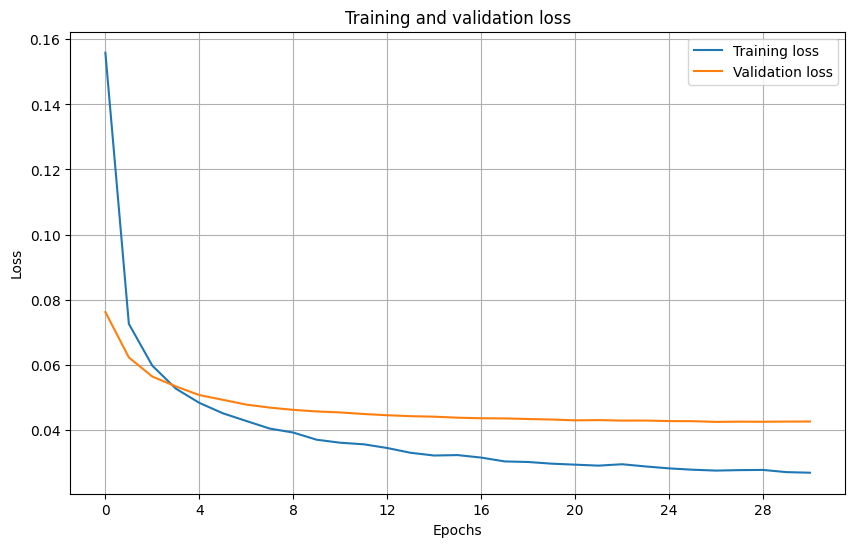

In [20]:
# visualize train and val loss
train_loss = history.history['loss']
val_loss = history.history.get('val_loss')

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

In [21]:
saving.save_model(model, model_path)

## Evaluation

In [22]:
test_accuracy = model.evaluate(test_ds)
print(f'Test accuracy: {test_accuracy[1] * 100:3.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9341 - loss: 0.0308
Test accuracy: 89.92%


In [23]:
test2_accuracy = model.evaluate(test2_ds)
print(f'Test2 accuracy: {test2_accuracy[1] * 100:3.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8823 - loss: 9.9267
Test2 accuracy: 86.82%


In [24]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # append true labels based on their format
    if len(labels.shape) > 1:  # if one-hot encoded
        true_labels.append(np.argmax(labels.numpy(), axis=1))
    else:  # if integer labels
        true_labels.append(labels.numpy())

    # predict labels
    predictions = model.predict(images)
    predicted_labels.append(np.argmax(predictions, axis=1))

# combine all batches into single arrays
true_labels = np.concatenate(true_labels)
predicted_labels = np.concatenate(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [25]:
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f'Precision: {precision * 100:3.2f}%; Recall: {recall * 100:3.2f}%; F1: {f1 * 100:3.2f}%')

Precision: 90.00%; Recall: 89.92%; F1: 89.93%


In [26]:
cr_dict = classification_report(true_labels, predicted_labels, target_names=class_names, output_dict=True)
cr_df = pd.DataFrame(cr_dict).transpose()
cr_df.to_csv(classification_report_path)
print('Classification report:\n', cr_df)

Classification report:
                   precision  recall  f1-score    support
tiger              1.000000  0.9960  0.997996   250.0000
leopard            0.919492  0.8680  0.893004   250.0000
black_bear         0.937984  0.9680  0.952756   250.0000
other_carnivores   0.926829  0.9120  0.919355   250.0000
deer               0.910569  0.8960  0.903226   250.0000
wild_boar          0.908730  0.9160  0.912351   250.0000
buffalo            0.891129  0.8840  0.887550   250.0000
rhino              0.842742  0.8360  0.839357   250.0000
elephant           0.861789  0.8480  0.854839   250.0000
bird               0.800738  0.8680  0.833013   250.0000
accuracy           0.899200  0.8992  0.899200     0.8992
macro avg          0.900000  0.8992  0.899345  2500.0000
weighted avg       0.900000  0.8992  0.899345  2500.0000


In [27]:
cm = confusion_matrix(true_labels, predicted_labels)
print('Confusion matrix:\n', cm)

Confusion matrix:
 [[249   0   0   0   0   0   1   0   0   0]
 [  0 217   2   2   2   4   3  13   5   2]
 [  0   0 242   0   3   1   1   0   1   2]
 [  0   1   0 228   1   5  11   1   1   2]
 [  0   4  10   2 224   6   1   0   2   1]
 [  0   3   0   2   6 229   1   3   1   5]
 [  0   4   0   7   2   3 221  10   0   3]
 [  0   3   2   3   2   1   8 209   9  13]
 [  0   1   1   2   2   1   0   5 212  26]
 [  0   3   1   0   4   2   1   7  15 217]]


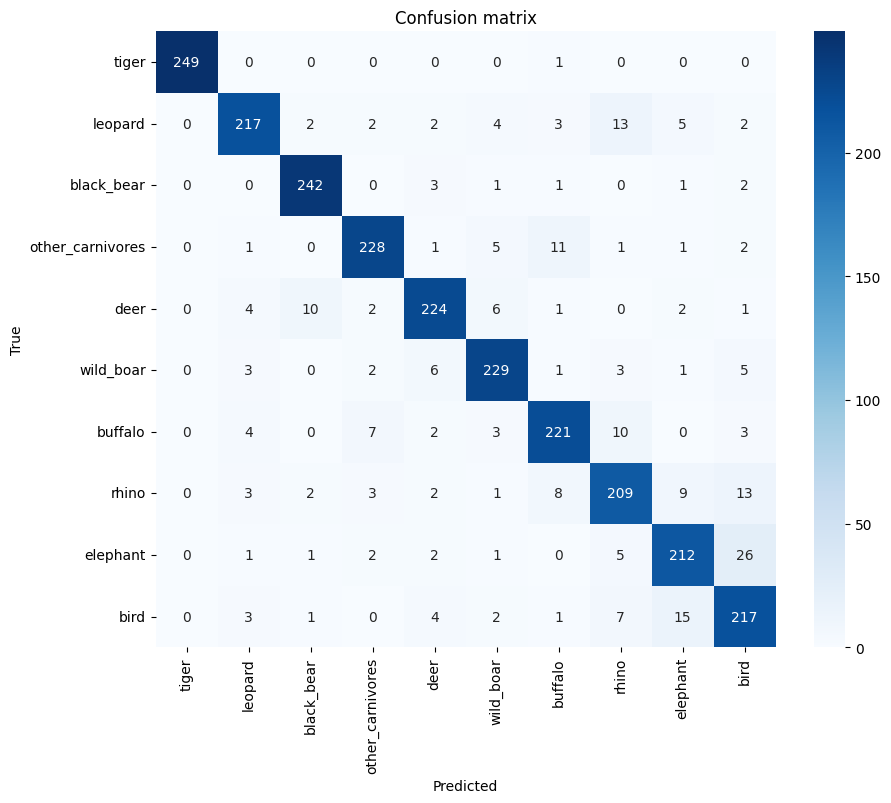

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

## Log run to W&B

In [29]:
if logging:
    run = wandb.init(
        project=wb_project,
        config={
            'model_constructor': model_constructor,
            'model_params': model_params,
            'frozen_file_size': frozen_file_size,
            'num_classes': num_classes,
            'n_train_images': n_train_images,
            'n_test_images': n_test_images,
            'batch_size': batch_size,
            'epochs': epochs,
        },
    )
    wandb.log({
        'training_time_mins': training_time_mins,
        'test_accuracy': round(test_accuracy[1], 4),
        'test2_accuracy': round(test2_accuracy[1], 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
    })
    artifact = wandb.Artifact('classification_results', type='evaluation')
    artifact.add_file(classification_report_path)
    artifact.add_file(confusion_matrix_path)
    wandb.log_artifact(artifact)
    wandb.finish()